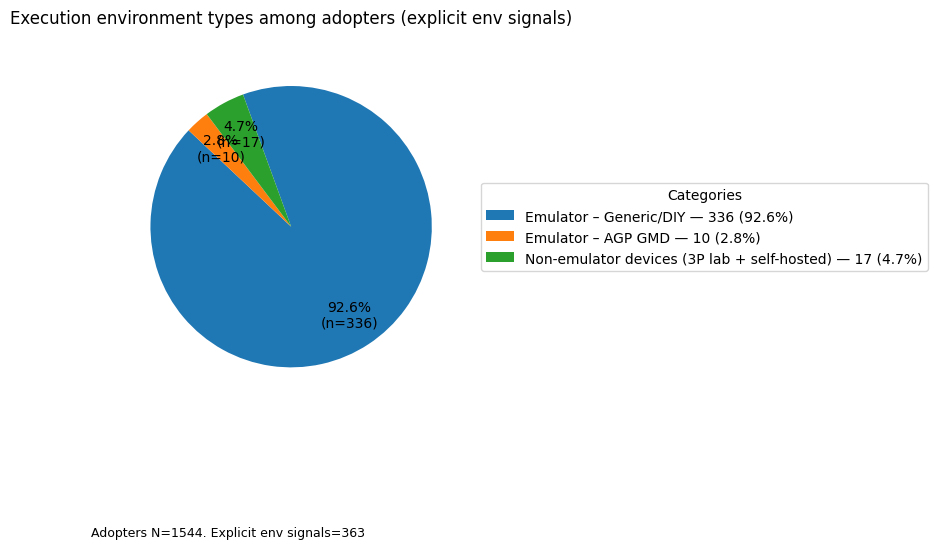

Dataset used: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_MR.csv
Adopters (N): 1544 | Explicit env signals: 363 | Unknown: 1181
Percentages normalized to: explicit


In [6]:
# -*- coding: utf-8 -*-
# Execution environment pie among adopters (explicit env signals)
# - Reads from your Windows folder (with safe fallbacks)
# - Uses RQ1_F1 == True
# - Merges "Third Party" + "Real Device" -> "Non-emulator devices (3P lab + self-hosted)"
# - Drops zero-count categories
# - NORMALIZE_TO: "explicit" (sum=100) or "all" (vs all adopters N)

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ========= CONFIG =========
MODE = "legend"         # "legend" or "labels"
NORMALIZE_TO = "explicit"  # "explicit" (sum=100) or "all"
WINDOWS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1")
PRIORITY_FILES = ["3.2_Total_Repo_MR.csv", "3.2_Total_Repo.csv", "Total_Repo_MR.csv", "Total_Repo.csv"]
FALLBACKS = [Path("/mnt/data/3.2_Total_Repo_MR.csv"), Path("/mnt/data/3.2_Total_Repo.csv")]
SAVE_TO = None  # e.g., r"C:\Android Mobile App\figs\execution_environment_MR_pie.png"
TITLE = "Execution environment types among adopters (explicit env signals)"

def choose_dataset_path():
    if WINDOWS_DIR.exists():
        for name in PRIORITY_FILES:
            p = WINDOWS_DIR / name
            if p.exists():
                return p
        csvs = sorted(WINDOWS_DIR.glob("*.csv"))
        for p in csvs:
            if "repo" in p.name.lower():
                return p
        if csvs:
            return csvs[0]
    for p in FALLBACKS:
        if p.exists():
            return p
    raise FileNotFoundError("Dataset not found in the Windows path or fallbacks.")

def map_env(value):
    """Map execution_environment_MR to display buckets; Unknown/None -> excluded."""
    if pd.isna(value) or str(value).strip().lower() in {"", "unknown", "none"}:
        return None
    s = str(value).strip().lower()
    if s == "emulator":
        return "Emulator – Generic/DIY"
    if s == "gmd":
        return "Emulator – AGP GMD"
    if s in {"third party", "real device"}:
        return "Non-emulator devices (3P lab + self-hosted)"
    return "Other/Unspecified"

def autopct_gen(counts, total):
    """Show % based on the chosen total + raw n."""
    def _autopct(_pct):
        idx = _autopct.idx
        _autopct.idx += 1
        c = counts[idx]
        if total == 0:
            return "0.0%\n(n=0)"
        return f"{(c/total*100):.1f}%\n(n={c})"
    _autopct.idx = 0
    return _autopct

# ========= LOAD & PREP =========
csv_path = choose_dataset_path()
df = pd.read_csv(csv_path)

if "RQ1_F1" not in df.columns:
    raise KeyError("Expected 'RQ1_F1' in dataset to flag adopters.")

adopters = df[df["RQ1_F1"] == True].copy()
N = len(adopters)

preferred_labels = [
    "Emulator – Generic/DIY",
    "Emulator – AGP GMD",
    "Non-emulator devices (3P lab + self-hosted)",
    "Other/Unspecified",
]

mapped = adopters["execution_environment_MR"].map(map_env)
explicit = mapped.dropna()
explicit_N = len(explicit)
unknown_N = N - explicit_N

# counts by label (zero-drop)
vc = explicit.value_counts()
labels = []
counts = []
for lab in preferred_labels:
    c = int(vc.get(lab, 0))
    if c > 0:
        labels.append(lab)
        counts.append(c)

# denominator for percentages
if NORMALIZE_TO.lower() == "explicit":
    total_for_pct = explicit_N
elif NORMALIZE_TO.lower() == "all":
    total_for_pct = N
else:
    raise ValueError("NORMALIZE_TO must be 'explicit' or 'all'.")

# ========= PLOT =========
title_text = TITLE + ("" if NORMALIZE_TO == "explicit"
                      else " — % shown vs all adopters")

if MODE == "labels":
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_axes([0.06, 0.06, 0.88, 0.88])
    ax.pie(
        counts,
        labels=labels,
        autopct=autopct_gen(counts, total_for_pct),
        startangle=110,
        counterclock=False,
        labeldistance=1.12,
        pctdistance=0.72,
    )
    ax.set_title(title_text, pad=26)
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])

elif MODE == "legend":
    fig = plt.figure(figsize=(9, 6.8))
    ax = fig.add_subplot(111)
    wedges, _, autotexts = ax.pie(
        counts,
        labels=None,
        autopct=autopct_gen(counts, total_for_pct),
        startangle=110,
        counterclock=False,
        pctdistance=0.75,
    )
    ax.set_title(title_text, pad=20)
    legend_labels = [f"{lab} — {counts[i]} ({counts[i]/total_for_pct*100:.1f}%)"
                     if total_for_pct > 0 else f"{lab} — {counts[i]} (n/a)"
                     for i, lab in enumerate(labels)]
    ax.legend(
        wedges, legend_labels,
        loc="center left", bbox_to_anchor=(1.0, 0.5),
        borderaxespad=1.0, title="Categories",
    )
    fig.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])

else:
    raise ValueError("MODE must be 'legend' or 'labels'.")

# Footnote clarifying Unknowns (helps auditors)
# caption = (f"Adopters N={N}. Explicit env signals={explicit_N} "
#            f"({explicit_N/N*100:.1f}% of adopters). "
#            f"Unknown={unknown_N} ({unknown_N/N*100:.1f}%).")
caption = (f"Adopters N={N}. Explicit env signals={explicit_N} ")

fig.text(0.01, 0.01, caption, ha="left", va="bottom", fontsize=9)

if SAVE_TO:
    plt.savefig(SAVE_TO, dpi=220, bbox_inches="tight")
plt.show()

print(f"Dataset used: {csv_path}")
print(f"Adopters (N): {N} | Explicit env signals: {explicit_N} | Unknown: {unknown_N}")
print(f"Percentages normalized to: {NORMALIZE_TO}")


In [10]:
# -*- coding: utf-8 -*-
"""
Build the Fully vs. Semi automation summary table from your main dataset.

Reads the CSV from:
C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1

Outputs a pandas DataFrame with columns:
Metric | Q1 (Fully) | Median (Fully) | Q3 (Fully) | Q1 (Semi) | Median (Semi) | Q3 (Semi)

Notes
- Uses RQ1_F1 == True to select adopters.
- Uses RQ1_F2 == 'Fully_Auto' vs 'Semi_Auto' to split classes.
- Derives rate metrics safely (avoids divide-by-zero).
- Prefers commits from 'commits_GitAPI' if present, else 'local_commit_count'.
- Prefers stars/forks from common GitHub field names.
"""

from pathlib import Path
import numpy as np
import pandas as pd

# -------- configuration --------
WINDOWS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1")
PRIORITY_FILES = [
    "3.2_Total_Repo_MR.csv",
    "3.2_Total_Repo.csv",
    "Total_Repo_MR.csv",
    "Total_Repo.csv",
]
# Optional fallback if you want to run this in another environment where a copy exists:
FALLBACKS = [Path("/mnt/data/3.2_Total_Repo_MR.csv"), Path("/mnt/data/3.2_Total_Repo.csv")]

# Column candidates (adjust/add if your schema differs)
COLS = {
    "prs": ["pull_requests", "prs", "total_prs"],
    "commits": ["commits_GitAPI", "local_commit_count", "commits"],
    "contributors": ["contributors", "num_contributors"],
    "age_years": ["repo_age", "age_years"],
    "size": ["size", "code_size", "loc"],
    "stars": ["stargazers_count", "stars"],
    "forks": ["forks_count", "forks"],
    "class": ["RQ1_F2", "automation_class", "class_f2"],
    "adopter": ["RQ1_F1", "Adopted_Primary", "adopted_primary", "is_adopter"],
}

# -------- helpers --------
def choose_dataset_path():
    if WINDOWS_DIR.exists():
        for name in PRIORITY_FILES:
            p = WINDOWS_DIR / name
            if p.exists():
                return p
        # otherwise first CSV in the folder (prefer names containing 'repo')
        csvs = sorted(WINDOWS_DIR.glob("*.csv"))
        for p in csvs:
            if "repo" in p.name.lower():
                return p
        if csvs:
            return csvs[0]
    for p in FALLBACKS:
        if p.exists():
            return p
    raise FileNotFoundError("Dataset not found in the Windows path or fallbacks.")

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the expected columns found: {candidates}")
    return None

def safe_div(num, den):
    # elementwise division with protection
    num = num.astype(float)
    den = den.astype(float)
    out = np.where((den > 0) & np.isfinite(den), num / den, np.nan)
    return pd.Series(out, index=num.index)

def q123(series):
    # return Q1, Median, Q3 on non-NaN values
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan, np.nan, np.nan
    return (np.quantile(s, 0.25), np.quantile(s, 0.50), np.quantile(s, 0.75))

def fmt(x):
    # pretty formatting: integers without .0, else two decimals
    if pd.isna(x):
        return ""
    if abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return f"{x:.2f}"

# -------- load --------
csv_path = choose_dataset_path()
df = pd.read_csv(csv_path)

adopter_col = first_existing(df, COLS["adopter"])
class_col = first_existing(df, COLS["class"])
prs_col = first_existing(df, COLS["prs"])
commits_col = first_existing(df, COLS["commits"])
contributors_col = first_existing(df, COLS["contributors"])
age_col = first_existing(df, COLS["age_years"])
size_col = first_existing(df, COLS["size"], required=False)
stars_col = first_existing(df, COLS["stars"], required=False)
forks_col = first_existing(df, COLS["forks"], required=False)

# -------- filter adopters and split classes --------
adopters = df[df[adopter_col] == True].copy()
# Normalize class labels if needed
class_map = {
    "Fully_Auto": "Fully",
    "Semi_Auto": "Semi",
    "CI_Only": "CI_Only",
    "Fully": "Fully",
    "Semi": "Semi",
}
adopters["Class"] = adopters[class_col].map(class_map).fillna(adopters[class_col])

fully = adopters[adopters["Class"] == "Fully"].copy()
semi = adopters[adopters["Class"] == "Semi"].copy()

# -------- derive metrics --------
# base columns
prs_f, prs_s = fully[prs_col], semi[prs_col]
comm_f, comm_s = fully[commits_col], semi[commits_col]
contrib_f, contrib_s = fully[contributors_col], semi[contributors_col]
age_f, age_s = fully[age_col], semi[age_col]

# per-year
prs_per_year_f = safe_div(prs_f, age_f)
prs_per_year_s = safe_div(prs_s, age_s)
comm_per_year_f = safe_div(comm_f, age_f)
comm_per_year_s = safe_div(comm_s, age_s)

# per-contributor
prs_per_contrib_f = safe_div(prs_f, contrib_f)
prs_per_contrib_s = safe_div(prs_s, contrib_s)
comm_per_contrib_f = safe_div(comm_f, contrib_f)
comm_per_contrib_s = safe_div(comm_s, contrib_s)

# commits per PR (granularity)
comm_per_pr_f = safe_div(comm_f, prs_f)
comm_per_pr_s = safe_div(comm_s, prs_s)

# optional fields
size_f = fully[size_col] if size_col else pd.Series(dtype=float)
size_s = semi[size_col] if size_col else pd.Series(dtype=float)
stars_f = fully[stars_col] if stars_col else pd.Series(dtype=float)
stars_s = semi[stars_col] if stars_col else pd.Series(dtype=float)
forks_f = fully[forks_col] if forks_col else pd.Series(dtype=float)
forks_s = semi[forks_col] if forks_col else pd.Series(dtype=float)

# -------- assemble Q1/Median/Q3 table --------
rows = [
    ("PRs/Year",            *q123(prs_per_year_f),        *q123(prs_per_year_s)),
    ("Commits/Year",        *q123(comm_per_year_f),       *q123(comm_per_year_s)),
    ("Commits/PR",          *q123(comm_per_pr_f),         *q123(comm_per_pr_s)),
    ("PRs/Contributor",     *q123(prs_per_contrib_f),     *q123(prs_per_contrib_s)),
    ("Commits/Contributor", *q123(comm_per_contrib_f),    *q123(comm_per_contrib_s)),
    ("PRs",                 *q123(prs_f),                 *q123(prs_s)),
    ("Commits",             *q123(comm_f),                *q123(comm_s)),
    ("Contributors",        *q123(contrib_f),             *q123(contrib_s)),
    ("AgeYears",            *q123(age_f),                 *q123(age_s)),
    ("Size",                *q123(size_f),                *q123(size_s)),
    ("Stars",               *q123(stars_f),               *q123(stars_s)),
    ("Forks",               *q123(forks_f),               *q123(forks_s)),
]

out = pd.DataFrame(
    rows,
    columns=[
        "Metric",
        "Q1 (Fully)", "Median (Fully)", "Q3 (Fully)",
        "Q1 (Semi)",  "Median (Semi)",  "Q3 (Semi)"
    ],
)

# Pretty-format numbers as strings (to mirror your example)
for col in out.columns[1:]:
    out[col] = out[col].map(fmt)

print(f"Dataset used: {csv_path}")
print(f"Fully n={len(fully)}, Semi n={len(semi)}")
print(out.to_string(index=False))

# Optional: save to CSV/Excel
out.to_csv(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\obs2_fully_vs_semi_table.csv", index=False)
# out.to_excel(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\obs2_fully_vs_semi_table.xlsx", index=False)


Dataset used: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_MR.csv
Fully n=342, Semi n=1170
             Metric Q1 (Fully) Median (Fully) Q3 (Fully) Q1 (Semi) Median (Semi) Q3 (Semi)
           PRs/Year       2.32          13.19      65.59      0.65          4.42     28.67
       Commits/Year      22.00          68.48     254.22     13.43         50.86    205.51
         Commits/PR       2.24           5.17      14.64      3.50          7.67     21.40
    PRs/Contributor       2.70           7.49      19.62      1.25          3.78     11.78
Commits/Contributor      24.04          45.87     105.48     21.73         47.69    108.95
                PRs         14          84.50        378      3.25            20    127.25
            Commits     152.50         469.50    1517.50        72        257.50    900.75
       Contributors          3              9         32         2             4        13
           AgeYears       4.53           7.43      